##### 8. Avaliação dos Modelos

Esta etapa tem como objetivo avaliar o desempenho dos modelos de Machine Learning treinados para detecção de phishing, utilizando métricas de classificação capazes de mensurar a capacidade preditiva, generalização e equilíbrio entre identificação de URLs legítimas e maliciosas.

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [2]:
# Carregamento dos dados

X_test = pd.read_csv("../data/output/test_train/X_test_output.csv")

y_test = pd.read_csv(
    "../data/output/test_train/y_test_output.csv"
).squeeze()

X_test_scaled = pd.read_csv(
    "../data/output/test_train/X_test_scaled_output.csv"
)

In [3]:
# Carregamento dos modelos treinados

log_model = joblib.load(
    "../data/output/models/logistic_regression.pkl"
)

tree_model = joblib.load(
    "../data/output/models/decision_tree.pkl"
)

rf_model = joblib.load(
    "../data/output/models/random_forest.pkl"
)

In [4]:
# Predições

# Regressão Logística
y_pred_log = log_model.predict(X_test_scaled)

# Decision Tree
y_pred_tree = tree_model.predict(X_test)

# Random Forest
y_pred_rf = rf_model.predict(X_test)

/home/barlettab/Documentos/Projects/phishing-machine-learning-cyber/phishing-machine-learning-cyber/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [5]:
# Métricas

def avaliar_modelo(nome, y_true, y_pred):
    
    print(f"\n===== {nome} =====")
    
    print("Accuracy:",
          accuracy_score(y_true, y_pred))
    
    print("Precision:",
          precision_score(y_true, y_pred))
    
    print("Recall:",
          recall_score(y_true, y_pred))
    
    print("F1-Score:",
          f1_score(y_true, y_pred))
    
    print("\nClassification Report:\n")
    
    print(classification_report(y_true, y_pred))

In [6]:
avaliar_modelo(
    "Regressão Logística",
    y_test,
    y_pred_log
)

avaliar_modelo(
    "Decision Tree",
    y_test,
    y_pred_tree
)

avaliar_modelo(
    "Random Forest",
    y_test,
    y_pred_rf
)


===== Regressão Logística =====
Accuracy: 0.952
Precision: 0.9448818897637795
Recall: 0.96
F1-Score: 0.9523809523809523

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1000
           1       0.94      0.96      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000


===== Decision Tree =====
Accuracy: 0.965
Precision: 0.9622266401590457
Recall: 0.968
F1-Score: 0.9651046859421735

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1000
           1       0.96      0.97      0.97      1000

    accuracy                           0.96      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.96      0.96      2000


===== Random Forest =====
Accuracy: 0.986
Precision: 0.987

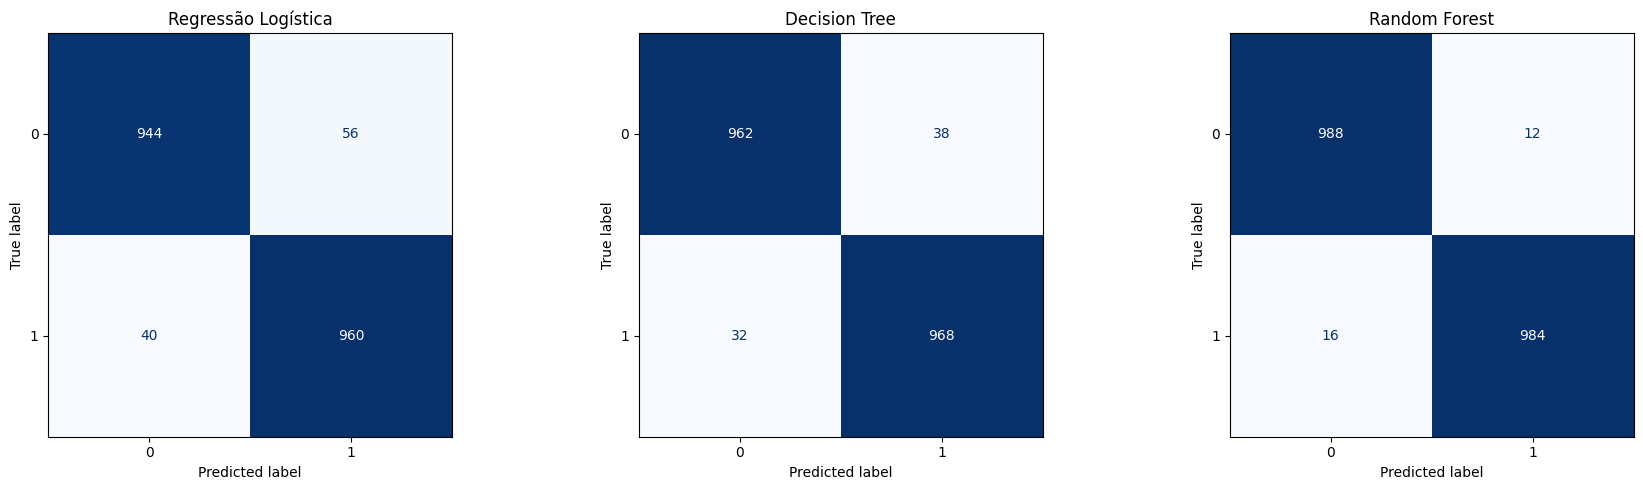

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Regressão Logística
cm_log = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(
    confusion_matrix=cm_log
).plot(
    ax=axes[0],
    cmap='Blues',
    values_format='d',
    colorbar=False
)

axes[0].set_title("Regressão Logística")


# Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree
).plot(
    ax=axes[1],
    cmap='Blues',
    values_format='d',
    colorbar=False
)

axes[1].set_title("Decision Tree")


# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
).plot(
    ax=axes[2],
    cmap='Blues',
    values_format='d',
    colorbar=False
)

axes[2].set_title("Random Forest")


plt.tight_layout()

plt.show()

| Modelo              | VP  | FN | FP | VN  |
| ------------------- | --- | -- | -- | --- |
| Regressão Logística | 944 | 56 | 40 | 960 |
| Decision Tree       | 962 | 38 | 32 | 968 |
| Random Forest       | 988 | 12 | 16 | 984 |

Observa-se que o modelo Random Forest apresentou o melhor desempenho entre os modelos avaliados, reduzindo significativamente a quantidade de falsos negativos e falsos positivos.

Em problemas de segurança cibernética, especialmente na detecção de phishing, minimizar falsos negativos é fundamental, pois esse tipo de erro representa URLs maliciosas classificadas como legítimas.

O modelo Random Forest apresentou apenas 12 falsos negativos, demonstrando elevada capacidade de identificar corretamente páginas phishing e maior capacidade de generalização em comparação aos demais modelos analisados. A combinação de múltiplas árvores de decisão no Random Forest contribuiu para maior estabilidade das previsões e redução de erros de classificação, especialmente em relação aos casos de phishing.

In [8]:
# Curva ROC - Regressão Logística
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Curva ROC - Decision Tree
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

# Curva ROC - Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

/home/barlettab/Documentos/Projects/phishing-machine-learning-cyber/phishing-machine-learning-cyber/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


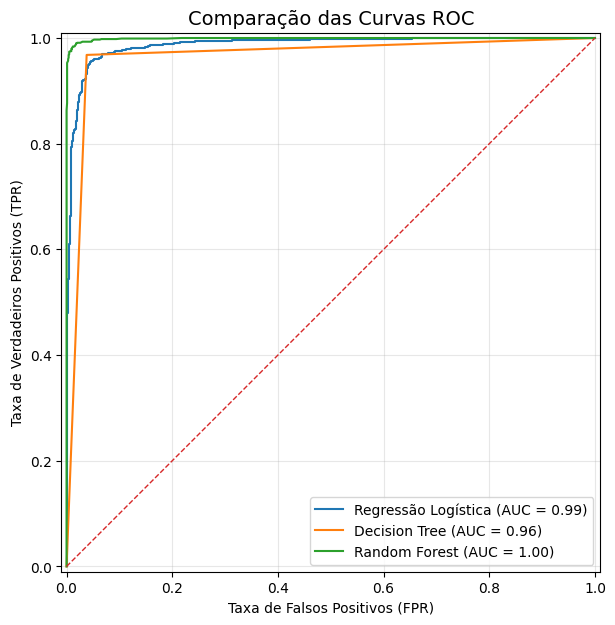

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

# Regressão Logística
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    name='Regressão Logística',
    ax=ax
)

# Decision Tree
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_tree,
    name='Decision Tree',
    ax=ax
)

# Random Forest
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name='Random Forest',
    ax=ax
)

# Linha aleatória
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

ax.set_title(
    "Comparação das Curvas ROC",
    fontsize=14
)

ax.set_xlabel(
    "Taxa de Falsos Positivos (FPR)"
)

ax.set_ylabel(
    "Taxa de Verdadeiros Positivos (TPR)"
)

ax.grid(alpha=0.3)

plt.show()

In [10]:
# Cálculo da AUC - Regressão Logística
auc_log = roc_auc_score(y_test, y_prob_log)

# Cálculo da AUC - Decision Tree
auc_tree = roc_auc_score(y_test, y_prob_tree)

# Cálculo da AUC - Random Forest
auc_rf = roc_auc_score(y_test, y_prob_rf)

In [11]:
print(f"AUC - Regressão Logística: {auc_log:.4f}")

print(f"AUC - Decision Tree: {auc_tree:.4f}")

print(f"AUC - Random Forest: {auc_rf:.4f}")

AUC - Regressão Logística: 0.9869
AUC - Decision Tree: 0.9650
AUC - Random Forest: 0.9990


| AUC       | Qualidade |
| --------- | --------- |
| 0.5       | aleatório |
| 0.6 - 0.7 | fraco     |
| 0.7 - 0.8 | razoável  |
| 0.8 - 0.9 | bom       |
| 0.9+      | excelente |


Os resultados obtidos através da métrica ROC-AUC demonstram elevada capacidade discriminatória dos modelos avaliados.

O modelo Random Forest apresentou o melhor desempenho, alcançando AUC de 0.9990, indicando capacidade quase perfeita de separação entre URLs legítimas e URLs phishing.

A Regressão Logística também apresentou desempenho elevado, sugerindo que o conjunto de atributos utilizado possui forte poder discriminatório mesmo em abordagens lineares.

Já a Decision Tree, apesar de apresentar desempenho satisfatório, demonstrou menor capacidade de generalização quando comparada ao modelo Random Forest.
